# Credit Card Fraud Dataset (DecodeLabs)

## Project 2

In [1]:
!pip install kaggle

!kaggle datasets download -d mlg-ulb/creditcardfraud

Dataset URL: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
License(s): DbCL-1.0
100% 66.0M/66.0M [00:00<00:00, 85.5MB/s]



In [2]:
import zipfile

with zipfile.ZipFile('creditcardfraud.zip', 'r') as zipf:
    zipf.extractall('dir')

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV #for hyperparam tuning
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_score, recall_score
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

## Data Loading

In [6]:
data = pd.read_csv("/content/dir/creditcard.csv")
print(data.shape)
data.info()
data.describe()

(284807, 31)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 2

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [8]:
data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## Class Distribution

Class
0    284315
1       492
Name: count, dtype: int64


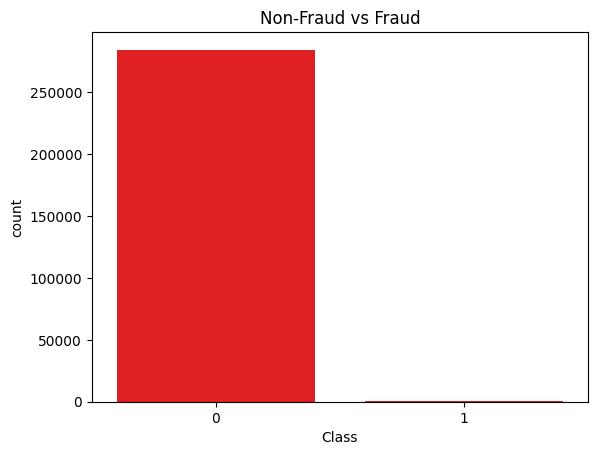

In [36]:
print(data["Class"].value_counts())

# 0 -> non-fraud
# 1 -> fraud

sns.countplot(x='Class', data=data, color = 'red')
plt.title("Non-Fraud vs Fraud")
plt.show()

## Data Splitting

In [12]:
X=data.drop("Class",axis=1)
y=data["Class"]

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

## Logistic Regression

In [15]:
logisticp=ImbPipeline(
    [
        ("smote", SMOTE(random_state=42)),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000))
    ]
)

In [16]:
logisticp.fit(X_train, y_train)

Pipeline(steps=[('smote', SMOTE(random_state=42)), ('scaler', StandardScaler()),
                ('model', LogisticRegression(max_iter=1000))])

In [18]:
y_predl=logisticp.predict(X_test)
y_probl=logisticp.predict_proba(X_test)[:,1] #all rows, fraud prob

# y_pred stores [0,0,1,0,1,0..]
# y_prob stores [
#                 [0.95,0.05],     -> 0
#                 [0.20,0.80],     -> 1
#                 [0.99,0.01]..    -> 0
#                              ]

In [19]:
print("Precision:", precision_score(y_test, y_predl))
print("Recall:", recall_score(y_test,y_predl))
print("ROC AUC Score:", roc_auc_score(y_test,y_probl))
print("Classification Report")
print(classification_report(y_test,y_predl))

Precision: 0.13414634146341464
Recall: 0.8979591836734694
ROC AUC Score: 0.9764816590676788
Classification Report
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     56864
           1       0.13      0.90      0.23        98

    accuracy                           0.99     56962
   macro avg       0.57      0.94      0.61     56962
weighted avg       1.00      0.99      0.99     56962



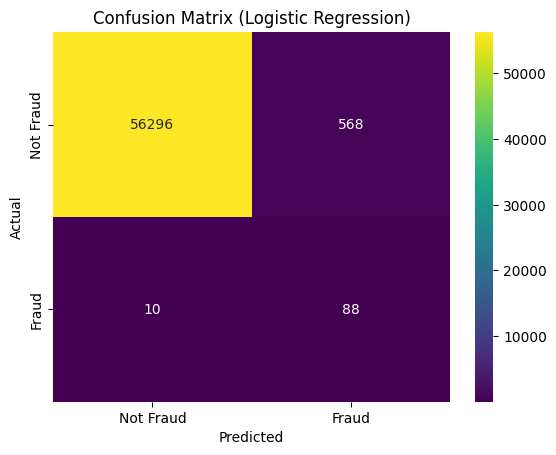

In [23]:
cm = confusion_matrix(y_test,y_predl)

sns.heatmap(cm,annot=True,fmt='d',cmap='viridis',xticklabels=['Not Fraud','Fraud'],yticklabels=['Not Fraud','Fraud'])
plt.title("Confusion Matrix (Logistic Regression)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Random Forest

In [25]:
rfp=ImbPipeline([
    ("smote",SMOTE(random_state=42)),
    ("model", RandomForestClassifier(random_state=42))
])

In [28]:
param = {
    "model__n_estimators":[50],
    "model__max_depth":[10,None]
}
grid = GridSearchCV(rfp,param,cv=2,scoring='recall',n_jobs=-1)

In [29]:
grid.fit(X_train,y_train)

GridSearchCV(cv=2,
             estimator=Pipeline(steps=[('smote', SMOTE(random_state=42)),
                                       ('model',
                                        RandomForestClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [10, None],
                         'model__n_estimators': [50]},
             scoring='recall')

In [30]:
best_model=grid.best_estimator_
print(grid.best_params_)

{'model__max_depth': 10, 'model__n_estimators': 50}


In [31]:
y_predrf=best_model.predict(X_test)
y_probrf=best_model.predict_proba(X_test)[:,1]

In [32]:
print("Precision:", precision_score(y_test, y_predrf))
print("Recall:", recall_score(y_test,y_predrf))
print("ROC AUC Score:", roc_auc_score(y_test,y_probrf))
print("Classification Report")
print(classification_report(y_test,y_predrf))

Precision: 0.514792899408284
Recall: 0.8877551020408163
ROC AUC Score: 0.9853427583751565
Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.51      0.89      0.65        98

    accuracy                           1.00     56962
   macro avg       0.76      0.94      0.83     56962
weighted avg       1.00      1.00      1.00     56962



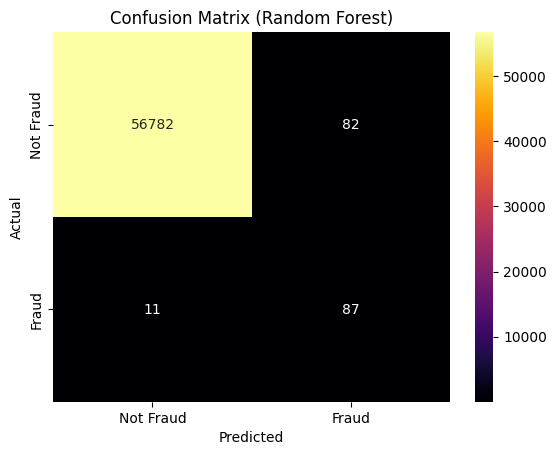

In [33]:
cm = confusion_matrix(y_test,y_predrf)

sns.heatmap(cm,annot=True,fmt='d',cmap='inferno',xticklabels=['Not Fraud','Fraud'],yticklabels=['Not Fraud','Fraud'])
plt.title("Confusion Matrix (Random Forest)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Comparison

In [34]:
comp = pd.DataFrame({
    "Model":["Logistic Regression","Random Forest"],
    "Precision":[precision_score(y_test,y_predl),precision_score(y_test,y_predrf)],
    "Recall":[recall_score(y_test,y_predl),recall_score(y_test,y_predrf)],
    "ROC AUC":[roc_auc_score(y_test,y_predl),roc_auc_score(y_test,y_predrf)],
})
print("COMPARISON RESULTS")
print(comp)

COMPARISON RESULTS
                 Model  Precision    Recall   ROC AUC
0  Logistic Regression   0.134146  0.897959  0.943985
1        Random Forest   0.514793  0.887755  0.943157


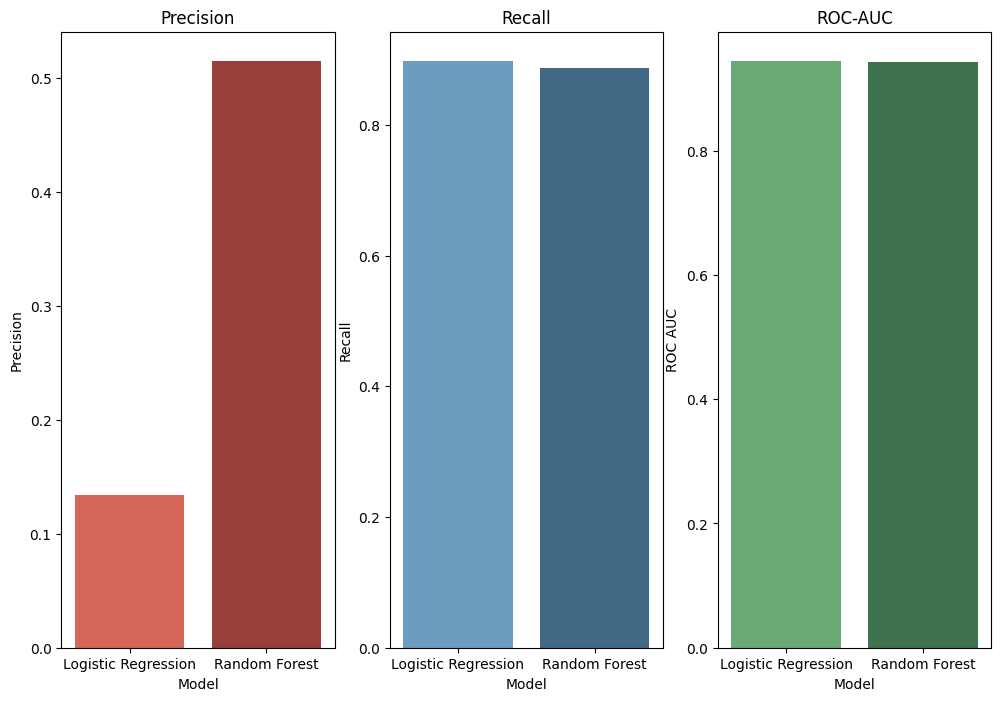

In [35]:
plt.figure(figsize=(12,8))

plt.subplot(1,3,1)
sns.barplot(x=comp["Model"],y=comp["Precision"], palette='Reds_d')
plt.title("Precision")

plt.subplot(1,3,2)
sns.barplot(x=comp["Model"],y=comp["Recall"], palette='Blues_d')
plt.title("Recall")

plt.subplot(1,3,3)
sns.barplot(x=comp["Model"],y=comp["ROC AUC"], palette='Greens_d')
plt.title("ROC-AUC")

plt.show()